# Expanding Training Set Full
The following Jupyter notebook is meant to merge the analysis for the various expanding training set functions from the affilitated notebooks, specifically regarding the reduced dataset. Repeat each of the following steps for the three main classifiers: Decision Tree, Logistic Regression, and Neural Net at every prediction week
1. Tuned the hyperparameters to ensure the most efficient model is utilized
2. Saving the specific performance metrics (Sensitivity, Specificity, Accuracy, Normalized MCC) 
3. Calculating the SHAP files for the various 9 columns
4. Saving each model to a .pkl file for every week

The various performace metrics and the SHAP values are saved to pickle, per classifier.


## Load Dependencies

In [1]:
#%reset
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn import metrics

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

from sklearn.metrics import accuracy_score, confusion_matrix, matthews_corrcoef
from num2words import num2words
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, matthews_corrcoef, roc_auc_score, average_precision_score
import word2number
from word2number import w2n
from sklearn.tree import DecisionTreeClassifier
import pickle
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
import random
from matplotlib.patches import Polygon
import shap
import os

from Functions import prep_training_test_data_period, prep_training_test_data, calculate_metrics,cross_validation_leave_geo_out, prep_training_test_data_shifted, add_labels_to_subplots, LOOCV_by_HSA_dataset, save_in_HSA_dictionary, prepare_data_and_model
hfont = {'fontname':'Helvetica'}
palette = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#e5c494']
import json 

## Load Data

In [2]:
HSA_weekly_data_all = pd.read_csv("HSA_Weekly_Surveillance.csv")

columns_to_remove = [col for col in HSA_weekly_data_all.columns if 'cases' in col]
HSA_weekly_data_no_cases_no_deaths = HSA_weekly_data_all.drop(columns=columns_to_remove)

columns_to_remove = [col for col in HSA_weekly_data_no_cases_no_deaths.columns if 'deaths' in col]
HSA_weekly_data_no_cases_no_deaths = HSA_weekly_data_no_cases_no_deaths.drop(columns=columns_to_remove)

HSA_weekly_data_all.loc[1, 'week_fifty-two_beds_over_15_100k']

0.0

In [3]:
HSA_weekly_data_all = HSA_weekly_data_all.loc[:, ~HSA_weekly_data_all.columns.str.startswith('Unnamed')]

## Define Global Variables

In [4]:
no_iterations = 100
geography_column = 'HSA_ID'
geo_split = 0.9
time_period = 'period'  # Choose 'period', 'exact', or 'shifted'
size_of_test_dataset = 1
train_weeks_for_initial_model = 1
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)

weeks_in_future = 3
weight_col = 'weight'
keep_output = True

# This is for SHAP Analysis - the order of the column names in the X_test files
feature_names=['COVID-19 admissions', 
               'COVID-19 ICU beds', 
               'COVID-19 hospital beds', 
               'Perc. beds with \nCOVID-19 patients', 
               '\u0394 COVID-19 admissions',
               '\u0394 COVID-19 ICU beds',
               '\u0394 COVID-19 hospital beds',
               '\u0394 Perc. beds with \nCOVID-19 patients',
               '> 15 per 100,000 COVID-19 \npatients in hospital beds']

# Just to check
print(len(feature_names))

9


## Location and County Data

In [5]:
## County Data 
data_by_county = pd.read_csv('county_time_data_all_dates.csv')

data_by_county = data_by_county.dropna(subset=['admits_weekly', 'deaths_weekly', 'cases_weekly', 'icu_weekly', 'beds_weekly', 'perc_covid'])
data_by_county['CTYNAME'] = data_by_county['CTYNAME'].apply(lambda x: x.split()[0])
data_by_county['CTYNAME'] = data_by_county['fips'].astype(str) + '' + data_by_county['CTYNAME']
data_by_county['beds_over_15_100k'] = (data_by_county['beds_weekly'] > 15) * 1

# Redo dates
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i

## DELTA POLYGON 
start_date = pd.to_datetime('2021-06-30')
end_date = pd.to_datetime('2021-10-26')
data_by_county['date'] = pd.to_datetime(data_by_county['date'])
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i
# Find the indices of rows that match the exact start and end dates
matching_indices_start = data_by_county.loc[data_by_county['date'] <= start_date].index.max()
matching_indices_end = data_by_county.loc[data_by_county['date'] <= end_date].index.max()
first_week_delta = data_by_county.loc[matching_indices_start, 'week']
last_week_delta = data_by_county.loc[matching_indices_end, 'week']
start_date = pd.to_datetime('2021-10-26')
end_date = pd.to_datetime('2022-09-27')
data_by_county['date'] = pd.to_datetime(data_by_county['date'])
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i
# Find the indices of rows that match the exact start and end dates
matching_indices_start = data_by_county.loc[data_by_county['date'] <= start_date].index.max()
matching_indices_end = data_by_county.loc[data_by_county['date'] <= end_date].index.max()
first_week_omricon = data_by_county.loc[matching_indices_start, 'week']
last_week_omricon = data_by_county.loc[matching_indices_end, 'week']

## CDC POLYGON 
start_date = pd.to_datetime('2021-03-01')
end_date = pd.to_datetime('2022-01-24')
data_by_county['date'] = pd.to_datetime(data_by_county['date'])
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i
# Find the indices of rows that match the exact start and end dates
matching_indices_start = data_by_county.loc[data_by_county['date'] <= start_date].index.max()
matching_indices_end = data_by_county.loc[data_by_county['date'] <= end_date].index.max()
first_week_CDC = data_by_county.loc[matching_indices_start, 'week']
last_week_CDC = data_by_county.loc[matching_indices_end, 'week']

/var/folders/b1/ts1cmy7n6kg0gzvxmtp8cc_80000gn/T/ipykernel_88365/873074510.py:2: DtypeWarning: Columns (47,48,49,50,51,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  data_by_county = pd.read_csv('county_time_data_all_dates.csv')


## Adding Percent Exceeding Capacity

In [6]:
percent_exceed_capacity = []

# Iterate through the columns of the DataFrame
for column_name in HSA_weekly_data_all.columns:
    if 'beds_over_15_100k' in column_name:
        # Calculate the sum of the column and append it to the list
        column_sum = HSA_weekly_data_all[column_name].sum() / len(HSA_weekly_data_all[column_name])
        percent_exceed_capacity.append(column_sum)

## Define Hyperparameter Tuning Functions

In [7]:
def hyperparameter_train_model_DT(X_train, y_train, sample_weights, decision_tree):   
    # Here are the hyperparamters
    param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(2, 5, 1)}
    
    # Now we construct the grid of hyperparamters to train
    grid_search = GridSearchCV(estimator=decision_tree,
                           param_grid=param_grid,
                           scoring='average_precision',  # Optimize for F1-score
                           cv=5,
                           n_jobs=-1, # This utilizes all cores in the CPU
                           verbose=1) 
    # Now evaluate
    grid_search.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Now we return the best model for usage
    best_model = grid_search.best_estimator_
    
    return best_model


def hyperparameter_train_model_LR(X_train, y_train, sample_weights, logistic):   
    # Here are the hyperparamters
    param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],            # Type of regularization
    'solver': ['liblinear', 'saga'],    # Solvers that support both l1 and l2
    'class_weight': [None, 'balanced']  # Handle imbalanced data
}
    # Now we construct the grid of hyperparamters to train
    grid_search = GridSearchCV(estimator=logistic,
                           param_grid=param_grid,
                           scoring='average_precision',  # Optimize for F1-score
                           cv=5,
                           n_jobs=-1, # This utilizes all cores in the CPU
                           verbose=1) 
    # Now evaluate
    grid_search.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Now we return the best model for usage
    best_model = grid_search.best_estimator_
    
    return best_model


def hyperparameter_train_model_NN(X_train, y_train, sample_weights, mlp):
    param_grid = {
        'hidden_layer_sizes': [(64,), (128,), (256,)],
        'learning_rate_init': [0.001, 0.01, 0.0001],
        'learning_rate': ['adaptive', 'constant'],
    }

    grid_search = GridSearchCV(
        estimator=mlp,
        param_grid=param_grid,
        scoring='average_precision',   # same as your LR helper; swap to 'f1_weighted' if preferred
        cv=5,
        n_jobs=-1,      # use all cores like LR helper
        verbose=1
    )

    grid_search.fit(X_train, y_train, sample_weight=sample_weights)
    
    return grid_search.best_estimator_

## Preparing Training Function

In [8]:
def prep_training_test_data(
    data, no_weeks, weeks_in_future, geography, weight_col, keep_output
):
    ## Get the weeks for the x and y datasets
    x_weeks = []
    y_weeks = []
    for week in no_weeks:
        test_week = int(week) + weeks_in_future
        x_weeks.append("_" + num2words(week) + "_")
        y_weeks.append("_" + num2words(test_week) + "_")
    X_data = pd.DataFrame()
    y_data = pd.DataFrame()
    weights_all = pd.DataFrame()
    missing_data = []
    ## Now get the training data
    k = 0
    for x_week in x_weeks:
        y_week = y_weeks[k]
        k += 1
        weeks_x = [col for col in data.columns if x_week in col]
        columns_x = [geography] + weeks_x + [weight_col]
        data_x = data[columns_x]
        weeks_y = [col for col in data.columns if y_week in col]
        columns_y = [geography] + weeks_y
        data_y = data[columns_y]
        # ensure they have the same amount of data
        # remove rows in test_data1 with NA in test_data2
        data_x = data_x.dropna()
        data_x = data_x[data_x[geography].isin(data_y[geography])]
        # remove rows in test_data2 with NA in test_data1
        data_y = data_y.dropna()
        data_y = data_y[data_y[geography].isin(data_x[geography])]
        data_x = data_x[data_x[geography].isin(data_y[geography])]
        data_x_no_HSA = len(data_x[geography].unique())
        missing_data.append(
            (
                (len(data[geography].unique()) - data_x_no_HSA)
                / len(data[geography].unique())
            )
            * 100
        )
        # get weights
        # weights = weight_data[weight_data[geography].isin(data_x[geography])][[geography, weight_col]]
        X_week = data_x.iloc[:, 1 : len(columns_x)]  # take away y, leave weights for mo
        y_week = data_y.iloc[:, -1]
        y_week = y_week.astype(int)
        weights = X_week.iloc[:, -1]
        if keep_output:
            X_week = X_week.iloc[
                :, : len(X_week.columns) - 1
            ]  # remove the weights and leave "target" for that week
            # rename columns for concatenation
            X_week.columns = range(1, len(data_x.columns) - 1)
        else:
            X_week = X_week.iloc[
                :, : len(X_week.columns) - 2
            ]  # remove the weights and  "target" for that week
            X_week.columns = range(
                1, len(data_x.columns) - 2
            )  # remove the weights and  "target" for that week
            # rename columns for concatenation
        y_week.rename("0", inplace=True)
        X_data = pd.concat([X_data, X_week], axis = 0)
        y_data = pd.concat([y_data, y_week], axis = 0)
        weights.rename("0", inplace=True)
        weights_all = pd.concat([weights_all, weights], axis = 0)
    X_data.reset_index(drop=True, inplace=True)
    y_data.reset_index(drop=True, inplace=True)
    weights_all.reset_index(drop=True, inplace=True)
    return (X_data, y_data, weights_all, missing_data)

## Preparing Folder for the Models

In [10]:
# Preparing folders for the different models
lr_folder = "logisticRegressionFolderFull"
nn_folder = "neuralNetworkFolderFull"

# Double check in-case folders are not prepared
def create_directory_if_not_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Created directory: {directory_path}")
    else:
        print(f"Directory already exists: {directory_path}")

# Now apply to the folder names
create_directory_if_not_exists(lr_folder)
create_directory_if_not_exists(nn_folder)

Directory already exists: logisticRegressionFolderFull
Directory already exists: neuralNetworkFolderFull


## Prepare Data Full

In [11]:
full_regex_pattern = (
    "HSA|weight|beds_over_15_100k|"
    "cases|deaths|admits|icu|beds|perc_covid"
)

columns_to_select_full = HSA_weekly_data_all.filter(
    regex=full_regex_pattern
).columns.tolist()

full_data = HSA_weekly_data_all[columns_to_select_full]

In [11]:
full_data.columns.tolist()

['HSA_ID',
 'week_one_cases',
 'week_one_deaths',
 'week_one_admits',
 'week_one_icu',
 'week_one_beds',
 'week_one_perc_covid',
 'week_one_cases_delta',
 'week_one_deaths_delta',
 'week_one_admits_delta',
 'week_one_icu_delta',
 'week_one_beds_delta',
 'week_one_perc_covid_delta',
 'week_one_beds_over_15_100k',
 'week_two_cases',
 'week_two_deaths',
 'week_two_admits',
 'week_two_icu',
 'week_two_beds',
 'week_two_perc_covid',
 'week_two_cases_delta',
 'week_two_deaths_delta',
 'week_two_admits_delta',
 'week_two_icu_delta',
 'week_two_beds_delta',
 'week_two_perc_covid_delta',
 'week_two_beds_over_15_100k',
 'week_three_cases',
 'week_three_deaths',
 'week_three_admits',
 'week_three_icu',
 'week_three_beds',
 'week_three_perc_covid',
 'week_three_cases_delta',
 'week_three_deaths_delta',
 'week_three_admits_delta',
 'week_three_icu_delta',
 'week_three_beds_delta',
 'week_three_perc_covid_delta',
 'week_three_beds_over_15_100k',
 'week_four_cases',
 'week_four_deaths',
 'week_four_a

## Loop - Logisitic Regression

In [ ]:
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)
ROC_by_week_lr_period = []
PRC_by_week_lr_period = [] # This is for the PRC graph
sensitivity_by_week_lr_period = []
specificity_by_week_lr_period = []
ppv_by_week_lr_period = []
npv_by_week_lr_period = []
accuracy_by_week_lr_period = []
norm_MCC_by_week_lr_period = []


size_of_test_dataset = 1
for prediction_week in weeks_to_predict:
    print(prediction_week)
    print(range(1 , int(prediction_week + train_weeks_for_initial_model) + 1))
    print(range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1))

    X_train_lr, y_train_lr, weights_lr, missing_data_train_HSA = prep_training_test_data(full_data, no_weeks=range(1, int(prediction_week + train_weeks_for_initial_model) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
    

    X_test_lr, y_test_lr, weights_test_lr, missing_data_test_HSA = prep_training_test_data(full_data, no_weeks=range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
    
    
    weights_lr = weights_lr.to_numpy()
    weights_lr = weights_lr.ravel()
    
    # Instantiate classifier
    clf_lr =  LogisticRegression(random_state=10, class_weight='balanced', max_iter=1000, solver='liblinear') 
    # Hyperparamter train
    best_clf_lr = hyperparameter_train_model_LR(X_train_lr, y_train_lr, weights_lr, clf_lr)
    
    # Now we save in our folder
    # Create filename
    model_to_save_lr = os.path.join(lr_folder, f"Full_model_week_{prediction_week}.pkl")
    
    # Saving the model using pickle
    with open(model_to_save_lr, "wb") as f:
        pickle.dump(best_clf_lr, f)

    # Make predictions on the test set
    y_pred = best_clf_lr.predict(X_test_lr)
    y_pred_proba = best_clf_lr.predict_proba(X_test_lr)

    # Evaluate the accuracy of the model
    accuracy_by_week_lr_period.append(accuracy_score(y_test_lr, y_pred))
    if len(np.unique(y_test_lr)) > 1:
    # Calculate ROC AUC score only if there are multiple classes
        ROC_by_week_lr_period.append(roc_auc_score(y_test_lr, y_pred_proba[:, 1]))
        PRC_by_week_lr_period.append(average_precision_score(y_test_lr, y_pred_proba[:, 1]))
    else:
        ROC_by_week_lr_period.append(np.nan)
        PRC_by_week_lr_period.append(np.nan)
    conf_matrix = confusion_matrix(y_test_lr, y_pred)

    sensitivity, specificity, ppv, npv = calculate_metrics(conf_matrix)
    sensitivity_by_week_lr_period.append(sensitivity)
    specificity_by_week_lr_period.append(specificity)

    ppv_by_week_lr_period.append(ppv)
    npv_by_week_lr_period.append(npv)

    norm_MCC_by_week_lr_period.append((matthews_corrcoef(y_test_lr, y_pred) + 1)/2)
'''
    # Time for SHAP Analysis LR
    X_test_lr.columns = feature_names
    
    # Need to pass background data for distribution estimation
    explainer_lr = shap.LinearExplainer(best_clf_lr, X_train_lr)
    shap_values_lr = explainer_lr(X_test_lr)

    # Concatenate all values
    if prediction_week == weeks_to_predict[0]:
        shap_values_all_lr = shap_values_lr
    else: # Concatenate the SHAP values
        for feature in X_test_lr.columns: 
                shap_values_all_lr.values = np.concatenate([shap_values_all_lr.values, shap_values_lr.values])
                shap_values_all_lr.base_values = np.concatenate([shap_values_all_lr.base_values, shap_values_lr.base_values])
                shap_values_all_lr.data = np.concatenate([shap_values_all_lr.data, shap_values_lr.data])
'''


## Saving Logistic Regression Performance Metrics

In [13]:
# Organize the file names
lr_performance_name = "full_lr_performance_stats.pkl"
lr_SHAP_name = "full_lr_SHAP.pkl"

# Organize into a dictionary
lr_performance_stats = {
    "ROC": ROC_by_week_lr_period,
    "PRC": PRC_by_week_lr_period,
    "accuracy": accuracy_by_week_lr_period,
    "sensitivity": sensitivity_by_week_lr_period,
    "specificity": specificity_by_week_lr_period,
    "ppv": ppv_by_week_lr_period,
    "npv": npv_by_week_lr_period,
    "MCC": norm_MCC_by_week_lr_period
}

# Open
with open(lr_performance_name, 'wb') as f:
    pickle.dump(lr_performance_stats, f)
# with open(lr_SHAP_name, 'wb') as f:
    # pickle.dump(shap_values_all_lr, f)

## Loop - Neural Network

In [ ]:
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)
ROC_by_week_nn_period = []
PRC_by_week_nn_period = [] # This is for the PRC graph
sensitivity_by_week_nn_period = []
specificity_by_week_nn_period = []
ppv_by_week_nn_period = []
npv_by_week_nn_period = []
accuracy_by_week_nn_period = []
norm_MCC_by_week_nn_period = []

size_of_test_dataset = 1
for prediction_week in weeks_to_predict:
    print(prediction_week)
    print(range(1 , int(prediction_week + train_weeks_for_initial_model) + 1))
    print(range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1))

    X_train_nn, y_train_nn, weights_nn, missing_data_train_HSA = prep_training_test_data(full_data, no_weeks=range(1, int(prediction_week + train_weeks_for_initial_model) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
    

    X_test_nn, y_test_nn, weights_test_nn, missing_data_test_HSA = prep_training_test_data(full_data, no_weeks=range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
    
    weights_nn = weights_nn.to_numpy()
    weights_nn = weights_nn.ravel()
    
    clf_nn = MLPClassifier(max_iter=1000)

    # Hyperparameter train - pass the imblearn pipeline
    best_clf_nn = hyperparameter_train_model_NN(X_train_nn, y_train_nn, weights_nn, clf_nn)

    # Save model (joblib or pickle)
    model_to_save_nn = os.path.join(nn_folder, f"Full_model_week_{prediction_week}.pkl")
        # Saving the model using pickle
    with open(model_to_save_nn, "wb") as f:
        pickle.dump(best_clf_nn, f)

    # Make predictions on the test set (pipeline exposes predict/predict_proba)
    y_pred = best_clf_nn.predict(X_test_nn)
    y_pred_proba = best_clf_nn.predict_proba(X_test_nn)

    # Evaluate the accuracy of the model
    accuracy_by_week_nn_period.append(accuracy_score(y_test_nn, y_pred))
    if len(np.unique(y_test_nn)) > 1:
    # Calculate ROC AUC score only if there are multiple classes
        ROC_by_week_nn_period.append(roc_auc_score(y_test_nn, y_pred_proba[:, 1]))
        PRC_by_week_nn_period.append(average_precision_score(y_test_nn, y_pred_proba[:, 1]))
    else:
        ROC_by_week_nn_period.append(np.nan)
        PRC_by_week_nn_period.append(np.nan)
    conf_matrix = confusion_matrix(y_test_nn, y_pred)

    sensitivity, specificity, ppv, npv = calculate_metrics(conf_matrix)
    sensitivity_by_week_nn_period.append(sensitivity)
    specificity_by_week_nn_period.append(specificity)

    ppv_by_week_nn_period.append(ppv)
    npv_by_week_nn_period.append(npv)

    norm_MCC_by_week_nn_period.append((matthews_corrcoef(y_test_nn, y_pred) + 1)/2)

'''
    # Time for SHAP Analysis NN
    X_test_nn.columns = feature_names
    X_train_nn.columns = feature_names
    
    # Need to pass background data for distribution estimation
    explainer_nn = shap.KernelExplainer(best_clf_nn.predict_proba, X_train_nn)
    shap_values_nn = explainer_nn(X_test_nn)

    # Concatenate all values
    if prediction_week == weeks_to_predict[0]:
        shap_values_all_nn = shap_values_nn
    else: # Concatenate the SHAP values
        for feature in X_test_nn.columns: 
                shap_values_all_nn.values = np.concatenate([shap_values_all_nn.values, shap_values_nn.values])
                shap_values_all_nn.base_values = np.concatenate([shap_values_all_nn.base_values, shap_values_nn.base_values])
                shap_values_all_nn.data = np.concatenate([shap_values_all_nn.data, shap_values_nn.data])
'''


## Saving Neural Net Performance Metrics

In [15]:
nn_performance_name = "full_nn_performance_stats.pkl"
nn_SHAP_name = "full_nn_SHAP.pkl"

# Organize into a dictionary
nn_performance_stats = {
    "ROC": ROC_by_week_nn_period,
    "PRC": PRC_by_week_nn_period,
    "accuracy": accuracy_by_week_nn_period,
    "sensitivity": sensitivity_by_week_nn_period,
    "specificity": specificity_by_week_nn_period,
    "ppv": ppv_by_week_nn_period,
    "npv": npv_by_week_nn_period,
    "MCC": norm_MCC_by_week_nn_period
}

# Open
with open(nn_performance_name, 'wb') as f:
    pickle.dump(nn_performance_stats, f)

# with open(nn_SHAP_name, 'wb') as f:
    # pickle.dump(shap_values_all_nn, f)

# Making Final Plots

In [9]:
with open('Full_dt_performance_stats.pkl', 'rb') as f:
    dt_stats = pickle.load(f)
with open('full_lr_performance_stats.pkl', 'rb') as f:
    lr_stats = pickle.load(f)
with open('full_nn_performance_stats.pkl', 'rb') as f:
    nn_stats = pickle.load(f)

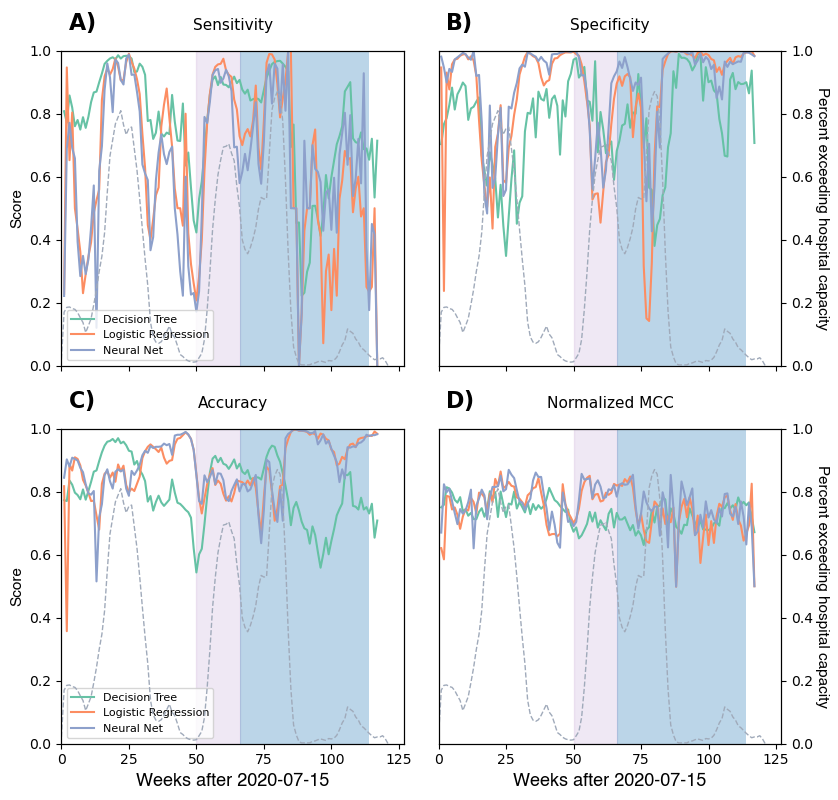

In [20]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 9), sharex='all')
axs = axs.ravel()

# Define the panel labels and plot content titles
panel_labels = ['A)', 'B)', 'C)', 'D)']
plot_content_titles = ["Sensitivity", "Specificity", "Accuracy", "Normalized MCC"]

for i, ax in enumerate(axs):
    ax.text(0.02, 1.05, r"$\mathbf{" + panel_labels[i] + "}$", transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left') # Changed fontsize from 13 to 16 (you can adjust)

    # Set the regular plot title (centered)
    ax.set_title(plot_content_titles[i], fontsize=11, loc='center', pad=15)

    # Plot the data
    key_name = plot_content_titles[i].lower().replace(" ", "_")
    if key_name == "normalized_mcc":
        key_name = "MCC"

    ax.plot(weeks_to_predict, dt_stats[key_name], label='Decision Tree', color=palette[0])
    ax.plot(weeks_to_predict, lr_stats[key_name], label='Logistic Regression', color=palette[1])
    ax.plot(weeks_to_predict, nn_stats[key_name], label='Neural Net', color=palette[2])


# Set axis labels for left-hand side
axs[0].set_ylabel('Score', **hfont, fontsize=11)
axs[2].set_ylabel('Score', **hfont, fontsize=11)

for i, ax in enumerate(axs):
    ax.set_ylim(0,1) # Set limits for all

    if i == 0 or i == 2: # Only for left column plots (0 and 2)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(axis='y', labelsize=10)
    else: # For right column plots (1 and 3)
        ax.set_yticks([]) # Clear major ticks
        ax.set_yticklabels([]) # Clear major tick labels
        ax.tick_params(axis='y', length=0) # Hide tick marks themselves

for i in range(0,4):
    second_axs = axs[i].twinx()
    second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    if i == 1 or i == 3: # For right column plots (1 and 3)
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 11,  labelpad=11)
    else:
        second_axs.set_yticks([]) # Clear major ticks
        second_axs.set_yticklabels([]) # Clear major tick labels
        second_axs.tick_params(axis='y', length=0) # Hide tick marks themselves

# Adding the legend
axs[0].legend(fontsize=8, ncol = 1, loc='lower left')
axs[2].legend(fontsize=8, ncol = 1, loc='lower left')

# Adding the x-axis label
for ax in axs: # Apply x-limits to all axs in a loop
    ax.set_xlim(0, 127)
    ax.set_xticks([0, 25, 50, 75, 100, 125])

axs[2].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)
axs[3].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)

# Add shaded regions (Polygons)
for ax in axs:
    # Polygon for 'delta' period
    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 1), (last_week_delta, 1), (last_week_delta, 0)],
                      alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)

    # Polygon for 'omricon' period
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 1), (last_week_omricon, 1), (last_week_omricon, 0)],
                      alpha=0.3)
    ax.add_patch(polygon_omricon)
fig.subplots_adjust(left=0., wspace=0.1) # Reduce horizontal space between columns

# Display
plt.savefig('All_Performances.png', dpi=300, bbox_inches='tight')
plt.show()

# Making Full AUROC and AUPRC plots

In [17]:
# Load in the data
stats_reduced_DT = None
stats_full_DT = None
stats_naive_DT = None
stats_CDC_DT = None
stats_reduced_lr = None
lr_full_ROC = None
lr_full_PRC = None
stats_reduced_nn = None
nn_full_ROC = None
nn_full_PRC = None

# Load in the iles
reduced_DT = "Reduced_dt_performance_stats.pkl"
full_DT = "Full_dt_performance_stats.pkl"
naive_DT = "Naive_dt_performance_stats.pkl"
CDC_DT = "CDC_dt_performance_stats.pkl"

with open(reduced_DT, 'rb') as f:
    stats_reduced_DT = pickle.load(f)

with open(full_DT, 'rb') as f:
    stats_full_DT = pickle.load(f)

with open(naive_DT, 'rb') as f:
    stats_naive_DT = pickle.load(f)
    
with open(CDC_DT, 'rb') as f:
    stats_CDC_DT = pickle.load(f)

# Logistic Regression
reduced_lr = "reduced_lr_performance_stats.pkl"
with open(reduced_lr, 'rb') as f:
    stats_reduced_lr = pickle.load(f)


full_lr_ROC = lr_stats["ROC"]
full_lr_PRC = lr_stats["PRC"]

# Neural Net
reduced_nn = "reduced_nn_performance_stats.pkl"
with open(reduced_nn, 'rb') as f:
    stats_reduced_nn = pickle.load(f)

full_nn_ROC = nn_stats["ROC"]
full_nn_PRC = nn_stats["PRC"]
    
CL_path = "CL_performance_stats.pkl"
with open(CL_path, 'rb') as f:
    CL_metrics = pickle.load(f)

weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)

In [18]:
dt_full_ROC = stats_full_DT['ROC']
dt_full_PRC = stats_full_DT['PRC']

dt_naive_ROC = stats_naive_DT['ROC']
dt_naive_PRC = stats_naive_DT['PRC']

dt_CDC_ROC = stats_CDC_DT['ROC']
dt_CDC_PRC = stats_CDC_DT['PRC']

dt_reduced_ROC = stats_reduced_DT['ROC']
dt_reduced_PRC = stats_reduced_DT['PRC']

lr_reduced_ROC = stats_reduced_lr['ROC']
lr_reduced_PRC = stats_reduced_lr['PRC']

nn_reduced_ROC = stats_reduced_nn['ROC']
nn_reduced_PRC = stats_reduced_nn['PRC']

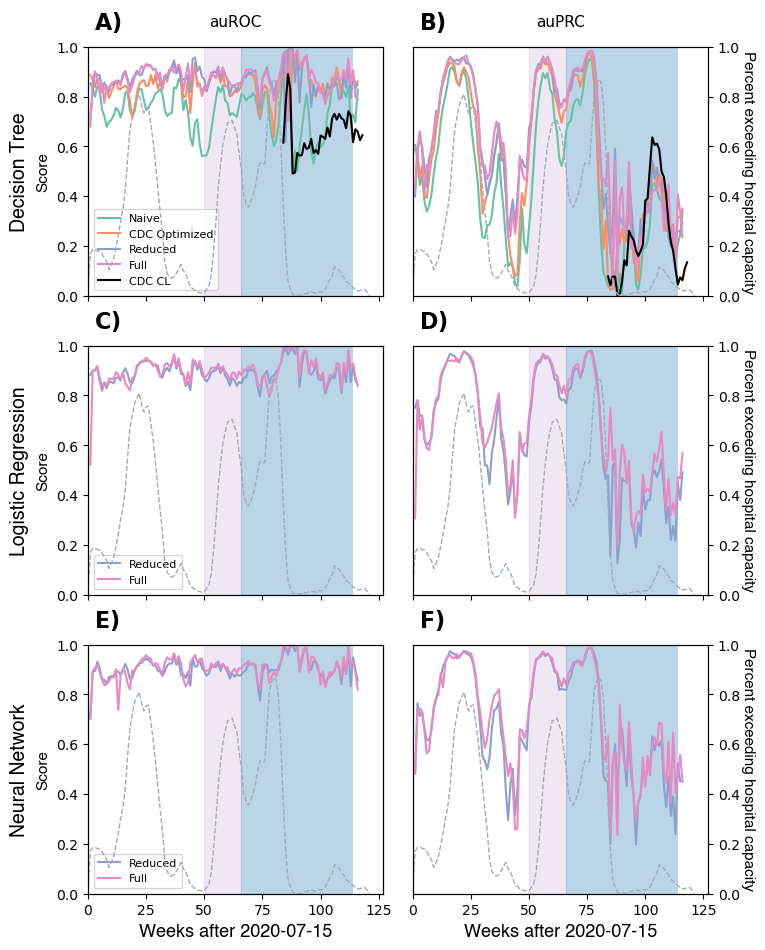

In [19]:
palette = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#000000', '#e5c494']

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 11), sharex='all')
axs = axs.ravel()

# Define the panel labels and plot content titles
panel_labels = ['A)', 'B)', 'C)', 'D)', 'E)', 'F)']
plot_content_titles = ["auROC", "auPRC", "", "", "", ""] 

for i, ax in enumerate(axs):
    ax.text(0.02, 1.05, r"$\mathbf{" + panel_labels[i] + "}$", transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left') 

    if plot_content_titles[i]: 
        ax.set_title(plot_content_titles[i], fontsize=11, loc='center', pad=15)

    if i == 0: # auROC - Decision Tree
        ax.plot(weeks_to_predict, dt_naive_ROC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, dt_CDC_ROC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, dt_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, dt_full_ROC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 1: # auPRC - Decision Tree
        ax.plot(weeks_to_predict, dt_naive_PRC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, dt_CDC_PRC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, dt_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, dt_full_PRC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 2: # auROC - Logistic Regression
        ax.plot(weeks_to_predict, lr_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, full_lr_ROC, label='Full', color=palette[3])
    elif i == 3: # auPRC - Logistic Regression
        ax.plot(weeks_to_predict, lr_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, full_lr_PRC, label='Full', color=palette[3])
    elif i == 4: # auROC - Neural Network
        ax.plot(weeks_to_predict, nn_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, full_nn_ROC, label='Full', color=palette[3])
    elif i == 5: # auPRC - Neural Network
        ax.plot(weeks_to_predict, nn_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, full_nn_PRC, label='Full', color=palette[3])


# Set axis labels for left-hand side
axs[0].set_ylabel('Score', **hfont, fontsize=11)
axs[2].set_ylabel('Score', **hfont, fontsize=11)
axs[4].set_ylabel('Score', **hfont, fontsize=11)

for i, ax in enumerate(axs):
    ax.set_ylim(0,1) 

    if i % 2 == 0:
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(axis='y', labelsize=10)
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.tick_params(axis='y', length=0) 

for i in range(0,6):
    second_axs = axs[i].twinx()
    second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    if i % 2 != 0: 
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 11,  labelpad=11)
    else:
        second_axs.set_yticks([]) # Clear major ticks
        second_axs.set_yticklabels([]) # Clear major tick labels
        second_axs.tick_params(axis='y', length=0) # Hide tick marks themselves

# Adding the legend
axs[0].legend(fontsize=8, ncol = 1, loc='lower left')
axs[2].legend(fontsize=8, ncol = 1, loc='lower left')
axs[4].legend(fontsize=8, ncol = 1, loc='lower left')

# Adding the x-axis label
for ax in axs: 
    ax.set_xlim(0, 127)

axs[4].set_xticks([0, 25, 50, 75, 100, 125])
axs[5].set_xticks([0, 25, 50, 75, 100, 125])

axs[4].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)
axs[5].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)

row_titles = ["Decision Tree", "Logistic Regression", "Neural Network"]
for i, title in enumerate(row_titles):

    ax_left = axs[i * 2]

    ax_left.text(-0.2, 0.5, title, transform=ax_left.transAxes, 
                 fontsize=14, va='center', ha='right', rotation=90, **hfont)


# Add shaded regions (Polygons)
for ax in axs:
    # Polygon for 'delta' period
    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 1), (last_week_delta, 1), (last_week_delta, 0)],
                      alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)

    # Polygon for 'omricon' period
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 1), (last_week_omricon, 1), (last_week_omricon, 0)],
                      alpha=0.3)
    ax.add_patch(polygon_omricon)

fig.subplots_adjust(wspace=0.1) 

# Display
plt.savefig('All_AUROC_AUPRC.png', dpi=300, bbox_inches='tight')
plt.show()


# Plotting Maximum Regret

## We need to organize the ROC and PRC

In [103]:
from Functions import calculate_maximum_reget
# Gather the model names and re-instantiate variables
models = ["Decision Tree", "Logistic Regression", "Neural Network"]
time_period = 'period'
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model-1)

all_models_auROC = {
    "ROC_by_week_dt": dt_reduced_ROC,
    "ROC_by_week_lr": lr_reduced_ROC,
    "ROC_by_week_nn": nn_reduced_ROC,
}

# Instanitate the dictionary
all_metrics = {}
all_metrics['ROC'] = all_models_auROC

maximum_regret_by_model_ROC = calculate_maximum_reget('ROC', all_metrics, models, time_period, weeks_to_predict)


# Now we do for the PRC
all_models_auPRC = {
    "PRC_by_week_dt": dt_reduced_PRC,
    "PRC_by_week_lr": lr_reduced_PRC,
    "PRC_by_week_nn": nn_reduced_PRC,
}

# Instanitate the dictionary
all_metrics = {}
all_metrics['PRC'] = all_models_auPRC

maximum_regret_by_model_PRC = calculate_maximum_reget('PRC', all_metrics, models, time_period, weeks_to_predict)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116


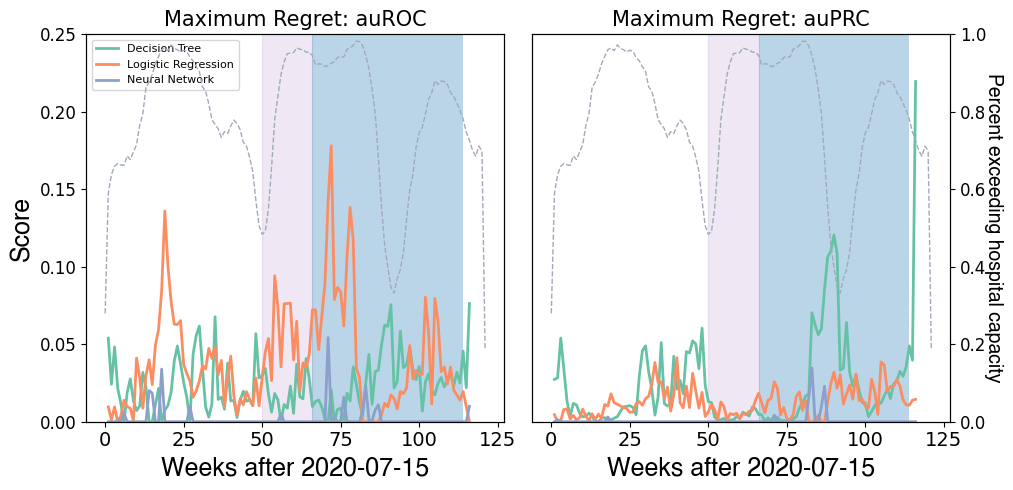

In [138]:
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model-1)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharex='all')
axs = axs.ravel()

# Here we plot the ROC for the first plot
for i, model in enumerate(models):
        colour = palette[i]
        axs[0].plot(weeks_to_predict, maximum_regret_by_model_ROC[model], label=model, linewidth = 2, color=colour)

axs[0].set_title("Maximum Regret: auROC", fontsize=15)
axs[1].set_title("Maximum Regret: auPRC", fontsize=15)
        
# Here we plot the PRC for the second plot
for i, model in enumerate(models):
        colour = palette[i]
        axs[1].plot(weeks_to_predict, maximum_regret_by_model_PRC[model], label=model, linewidth = 2, color=colour)

for i in range(0,2):
    second_axs = axs[i].twinx()
    second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    if i == 1 or i == 3 or i == 5:
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.tick_params(axis='y', labelsize=12)
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 14,  labelpad=12)
    else:
        second_axs.set_yticks([]) # Clear major ticks
        second_axs.set_yticklabels([]) # Clear major tick labels
        second_axs.tick_params(axis='y', length=0) # Hide tick marks themselves

axs[1].set_yticks([])
axs[0].set_yticks([0, 0.05, 0.1, 0.15, 0.2, 0.25])

axs[1].set_xticks([0, 25, 50, 75, 100, 125])
axs[0].set_xticks([0, 25, 50, 75, 100, 125])

for ax in axs:
    ax.set_xlabel('Weeks after 2020-07-15', **hfont, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)

    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 100000), (last_week_delta, 100000),
                             (last_week_delta, 0)],
                            alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 100000), (last_week_omricon, 100000),
                               (last_week_omricon, 0)],
                              alpha=0.3)
    ax.add_patch(polygon_omricon)
plt.tight_layout() # Reduce the width between plots
axs[0].set_ylabel('Score', **hfont, fontsize=18) # Add 1 label for the y-axis RHS

axs[0].tick_params(axis='y', which='both', labelsize=12)

axs[0].set_ylim(0,0.25)
axs[1].set_ylim(0,0.25)


axs[0].legend(fontsize = 8,ncol=1, loc='upper left')

plt.savefig('MR_AUROC_AUPRC.png', dpi=300, bbox_inches='tight')
plt.show()